In [ ]:
!git clone https://github.com/ccastore/sed_dis.git
!pip install onnxruntime

fatal: destination path 'sed_dis' already exists and is not an empty directory.


In [ ]:
import onnxruntime as ort
import matplotlib.pyplot as plt
import numpy as np
from sed_dis.scripts.processing import load_audio, predict

In [ ]:
model_type="YOLO"
providers=['CPUExecutionProvider']
clases=["Horn","Siren","Pets","Physiological","Speech","Ring Tone","Vibrating","Notifications","Cry"] #List of predictions
ort_sess = ort.InferenceSession('/content/sed_dis/models/YOLOv5n_original.onnx', providers=providers)


In [ ]:
import onnxruntime as ort
import matplotlib.pyplot as plt
import numpy as np
from sed_dis.scripts.processing import load_audio, predict

model_type = "YOLO"
providers = ['CPUExecutionProvider']
clases = ["Horn", "Siren", "Pets", "Physiological", "Speech", "Ring Tone", "Vibrating", "Notifications", "Cry"]

ort_sess = ort.InferenceSession('/content/sed_dis/models/YOLOv5n_original.onnx', providers=providers)

# --- Cargar audio completo ---
audio = load_audio("/content/20260424_12_07_05_0943_M1.wav", sr=16000)

# --- Parámetros ---
SR = 16000
CHUNK_DURATION = 10          # segundos que espera el modelo
CHUNK_SIZE = SR * CHUNK_DURATION  # 160,000 samples
THRESHOLD = 0.1

# --- Dividir en chunks de 10s y predecir ---
all_predictions = []
num_chunks = int(np.ceil(len(audio) / CHUNK_SIZE))

for i in range(num_chunks):
    start_sample = i * CHUNK_SIZE
    end_sample   = start_sample + CHUNK_SIZE
    chunk_offset = i * CHUNK_DURATION  # segundos desde el inicio del audio original

    # Extraer chunk y rellenar con ceros si es el último (< 10s)
    chunk = audio[start_sample:end_sample]
    audio_aux = np.zeros(CHUNK_SIZE, dtype=np.float32)
    audio_aux[:len(chunk)] = chunk

    # Predecir
    preds = predict(audio_aux, ort_sess, model_type, THRESHOLD)[0]

    # Ajustar onset/offset al tiempo real del audio completo
    for pred in preds:
        onset, offset, class_idx, confidence = pred
        all_predictions.append({
            "onset":      onset + chunk_offset,
            "offset":     offset + chunk_offset,
            "class":      clases[int(class_idx)],
            "confidence": confidence,
            "chunk":      i
        })

print(f"Total chunks procesados: {num_chunks}")
print(f"Total predicciones: {len(all_predictions)}")
all_predictions

Total chunks procesados: 1
Total predicciones: 2


[{'onset': np.float64(1.311020016670227),
  'offset': np.float64(1.4239188432693481),
  'class': 'Physiological',
  'confidence': np.float64(0.7367586493492126),
  'chunk': 0},
 {'onset': np.float64(3.4934258460998535),
  'offset': np.float64(3.732743978500366),
  'class': 'Physiological',
  'confidence': np.float64(0.18558305501937866),
  'chunk': 0}]

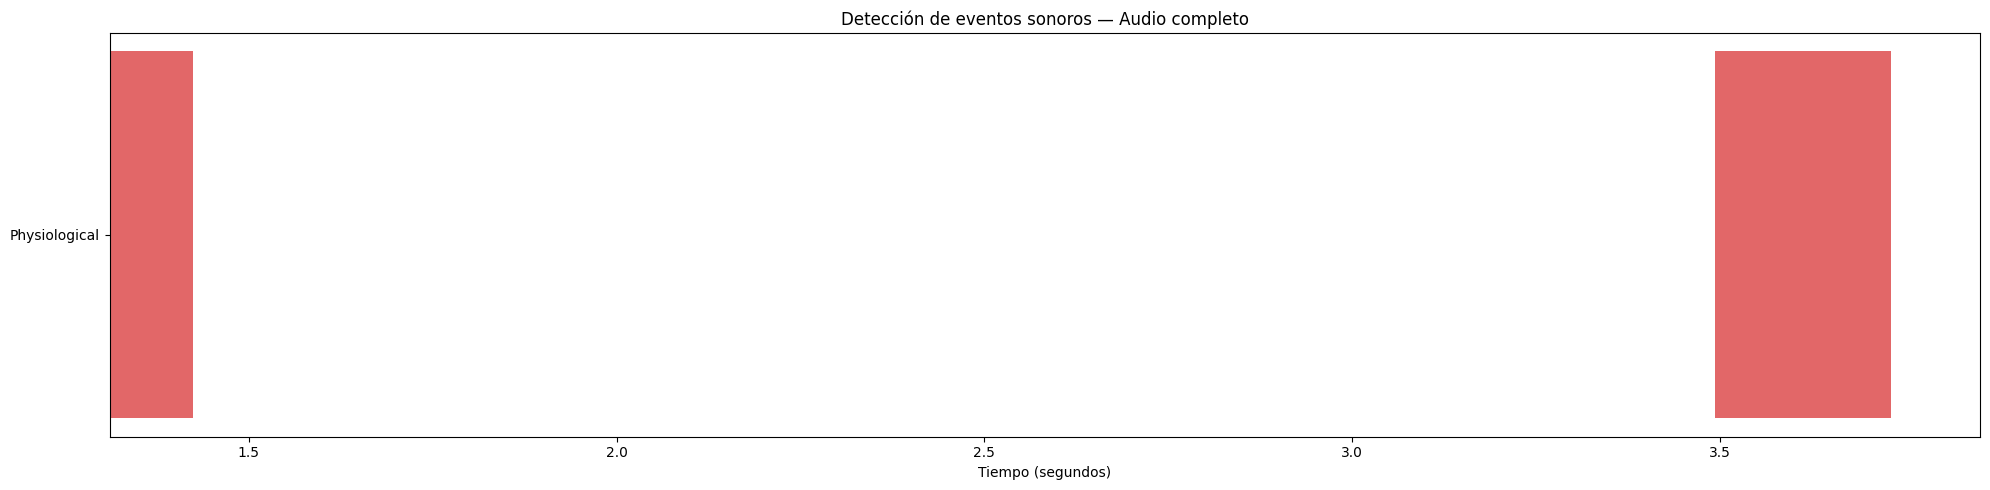

In [ ]:
fig, ax = plt.subplots(figsize=(20, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(clases)))
color_map = {c: colors[i] for i, c in enumerate(clases)}

for pred in all_predictions:
    ax.barh(
        pred["class"],
        pred["offset"] - pred["onset"],
        left=pred["onset"],
        color=color_map[pred["class"]],
        alpha=0.7
    )

ax.set_xlabel("Tiempo (segundos)")
ax.set_title("Detección de eventos sonoros — Audio completo")
plt.tight_layout()
plt.show()

# Prueba para esuchar los audios

In [ ]:
import numpy as np
import soundfile as sf
import os
from sed_dis.scripts.processing import load_audio

# --- Config ---
SR = 16000
AUDIO_PATH = "/content/20260424_12_07_05_0943_M1.wav"
OUTPUT_DIR = "/content/clips_por_clase"
MERGE_GAP = 1.0      # segundos: si dos detecciones están más cerca que esto, se fusionan
PADDING    = 0.5     # segundos de contexto antes y después de cada clip

audio = load_audio(AUDIO_PATH, sr=SR)
audio_duration = len(audio) / SR

os.makedirs(OUTPUT_DIR, exist_ok=True)

def merge_intervals(predictions_for_class, gap=1.0, padding=0.5, total_duration=None):
    """Fusiona detecciones cercanas y añade padding."""
    if not predictions_for_class:
        return []

    # Ordenar por onset
    intervals = sorted([(p["onset"], p["offset"]) for p in predictions_for_class])

    merged = [list(intervals[0])]
    for onset, offset in intervals[1:]:
        if onset - merged[-1][1] <= gap:
            merged[-1][1] = max(merged[-1][1], offset)  # extender
        else:
            merged.append([onset, offset])

    # Aplicar padding
    result = []
    for start, end in merged:
        start = max(0, start - padding)
        end   = min(total_duration, end + padding)
        result.append((start, end))

    return result

# --- Agrupar predicciones por clase ---
from collections import defaultdict
preds_by_class = defaultdict(list)
for pred in all_predictions:
    preds_by_class[pred["class"]].append(pred)

# --- Exportar clips ---
summary = {}
for clase, preds in preds_by_class.items():
    intervals = merge_intervals(preds, gap=MERGE_GAP, padding=PADDING, total_duration=audio_duration)

    clase_dir = os.path.join(OUTPUT_DIR, clase.replace(" ", "_"))
    os.makedirs(clase_dir, exist_ok=True)

    clips_info = []
    for idx, (start, end) in enumerate(intervals):
        start_sample = int(start * SR)
        end_sample   = int(end   * SR)
        clip = audio[start_sample:end_sample]

        filename = f"{clase.replace(' ','_')}_{idx+1:03d}_{int(start)}s-{int(end)}s.wav"
        filepath = os.path.join(clase_dir, filename)
        sf.write(filepath, clip, SR)
        clips_info.append({"file": filename, "start": start, "end": end, "duration": end - start})

    summary[clase] = clips_info
    print(f"✅ {clase}: {len(preds)} detecciones → {len(intervals)} clips guardados en '{clase_dir}'")

print(f"\n📁 Clips guardados en: {OUTPUT_DIR}")

✅ Physiological: 2 detecciones → 2 clips guardados en '/content/clips_por_clase/Physiological'

📁 Clips guardados en: /content/clips_por_clase


In [ ]:
import pandas as pd

rows = []
for clase, clips in summary.items():
    for clip in clips:
        rows.append({
            "Clase": clase,
            "Archivo": clip["file"],
            "Inicio (s)": round(clip["start"], 1),
            "Fin (s)":    round(clip["end"], 1),
            "Duración (s)": round(clip["duration"], 1)
        })

df_summary = pd.DataFrame(rows).sort_values(["Clase", "Inicio (s)"])
print(df_summary.to_string(index=False))

        Clase                     Archivo  Inicio (s)  Fin (s)  Duración (s)
Physiological Physiological_001_0s-1s.wav         0.8      1.9           1.1
Physiological Physiological_002_2s-4s.wav         3.0      4.2           1.2


#Escuchar audios

In [ ]:
from IPython.display import Audio, display

# Escuchar todos los clips de una clase concreta
CLASE_A_ESCUCHAR = "Physiological"  # ← cambia aquí

for clip in summary[CLASE_A_ESCUCHAR]:
    clase_dir = os.path.join(OUTPUT_DIR, CLASE_A_ESCUCHAR.replace(" ", "_"))
    filepath  = os.path.join(clase_dir, clip["file"])
    print(f"🔊 {clip['file']}  ({clip['start']:.1f}s → {clip['end']:.1f}s)")
    #confianza prediccion
    print(f"Confianza: {clip.get('confidence', 'No disponible')}")
    display(Audio(filepath))

🔊 Physiological_001_0s-1s.wav  (0.8s → 1.9s)
Confianza: No disponible


🔊 Physiological_002_2s-4s.wav  (3.0s → 4.2s)
Confianza: No disponible
